In [1]:
##tools
import arxiv
from langchain.tools import tool


In [2]:
def search_arxiv(query: str, max_results: int = 2):
    client = arxiv.Client(
        page_size=5,
        delay_seconds=3,
        num_retries=3
    )
    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.Relevance
    )
    results = client.results(search)
    return results

In [3]:
@tool
def arxiv_search(query: str, max_results: int = 2):
    """Search arXiv for papers matching the query."""
    results = search_arxiv(query, max_results)
    return "\n".join([f"{result.title} ({result.pdf_url})" for result in results])

In [2]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [3]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=200)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki, description="Useful for when you need to answer questions about general knowledge.")
wiki

WikipediaQueryRun(description='Useful for when you need to answer questions about general knowledge.', api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\racha\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=2, lang='en', load_all_available_meta=False, doc_content_chars_max=200))

In [7]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROK_API_KEY"] = os.getenv("GROK_API_KEY")

In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\racha\AppData\Local\Temp\ipykernel_26212\735679136.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [9]:
tavily.invoke("gimme the recent ai news")

[{'title': 'Agentic AI News + AI Breakthroughs + AI Developments | 2026',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': "Wondering what's happening in the AI world? Here are the latest AI breakthroughs and news that are shaping the world around us!",
  'score': 0.990732},
 {'title': 'AI News | Latest Headlines and Developments | Reuters',
  'url': 'https://www.reuters.com/technology/artificial-intelligence/',
  'content': "AI Weekly: major partner shifts and new medicine · AI Weekly: Chipmakers earnings charge, Anthropic's cybersecurity fears · AI Weekly: Anthropic's blacklisting",
  'score': 0.99036634},
 {'title': 'The trends that will shape AI and tech in 2026 | IBM',
  'url': 'https://www.ibm.com/think/news/ai-tech-trends-predictions-2026',
  'content': '2024 ended on a high note for open-source AI with Meta’s Llama models gaining traction. Since then, the open-source AI ecosystem has grown a lot, with smaller, domain-specific models achieving im

In [21]:
##combine all these tools
tools = [wiki, tavily, arxiv_search]

In [22]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", api_key=os.getenv("GROK_API_KEY"))

In [17]:
llm.invoke("What are the recent news about ai?")

AIMessage(content="Here are some recent news about AI:\n\n1. **Google's Bard AI:** In February 2023, Google released its AI chatbot, Bard, which competes with Microsoft's Bing Chat. Bard is a conversational AI that uses natural language processing (NLP) to understand and respond to user queries.\n\n2. **ChatGPT and DALL-E:** In December 2022, OpenAI released ChatGPT, a conversational AI that uses NLP to understand and respond to user queries. ChatGPT has gained massive popularity due to its ability to generate human-like responses. DALL-E, another AI model from OpenAI, can generate images from text prompts.\n\n3. **Microsoft's AI Integration:** In March 2023, Microsoft announced its plans to integrate AI into its products, including Office and Bing. The company aims to use AI to enhance user experiences and improve productivity.\n\n4. **AI-generated Art and Music:** AI-generated art and music have been gaining popularity in recent times. In 2023, an AI-generated song by Amper Music won

In [23]:
llm_with_tools = llm.bind_tools(tools=tools)

In [24]:
llm_with_tools.invoke("what is the latest research on quantum computing?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gvb3b81ek', 'function': {'arguments': '{"max_results":5,"query":"quantum computing"}', 'name': 'arxiv_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 429, 'total_tokens': 453, 'completion_time': 0.033794015, 'completion_tokens_details': None, 'prompt_time': 0.228363594, 'prompt_tokens_details': None, 'queue_time': 0.053925069, 'total_time': 0.262157609}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e44ce-6619-78c2-b4da-3b71e1623940-0', tool_calls=[{'name': 'arxiv_search', 'args': {'max_results': 5, 'query': 'quantum computing'}, 'id': 'gvb3b81ek', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 429, 'output_tokens': 24, 'total_tokens': 453})

In [36]:
##workflow using langgraph
from typing_extensions import TypedDict
from typing import Annotated   ## for type annotations
from langchain_core.messages import AnyMessage## human message or ai message
from langgraph.graph.message import add_messages ##reducers in langgraph

In [31]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages] ## this is the reducer, it will add messages to the state
    # list of all the ai, sys and human messages in the conversation history
    #add_messages doesnt override it appends to it, so we can keep track of the conversation history

In [ ]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


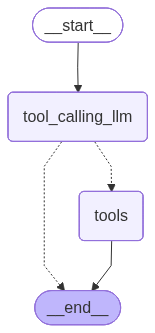

In [34]:
##node definitions
def tool_calling_llm(state: State):
    ##call the llm with tools and get the response
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##build the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

##edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [37]:
messages = graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv_search (87r6yjqqh)
 Call ID: 87r6yjqqh
  Args:
    max_results: 1
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv_search

Attention Is All You Need (https://arxiv.org/pdf/1706.03762v7)


In [ ]:
messages = graph.invoke({"messages" : "go through the recent quantum computing news and gimme the summary of them"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

go through the recent quantum computing news and gimme the summary of them
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (2crqj90rd)
 Call ID: 2crqj90rd
  Args:
    query: quantum computing recent news
  tavily_search_results_json (tnt695hac)
 Call ID: tnt695hac
  Args:
    query: quantum computing recent developments
  tavily_search_results_json (7b8y20y50)
 Call ID: 7b8y20y50
  Args:
    query: quantum computing recent breakthroughs
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Quantum Computing Is Beginning to Take Shape — Here Are Three Recent Breakthroughs  | Discover Magazine", "url": "https://www.discovermagazine.com/quantum-computing-is-beginning-to-take-shape-here-are-three-recent-breakthroughs-48938", "content": "More recently, other hardwar

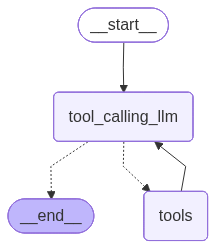

In [39]:
##node definitions
def tool_calling_llm(state: State):
    ##call the llm with tools and get the response
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##build the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

##edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm") ## we want to go back to the llm after calling the tools, so it can decide if it needs to call more tools or give the final answer

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [40]:
messages = graph.invoke({"messages" : "go through the recent quantum computing news and gimme the summary of them"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

go through the recent quantum computing news and gimme the summary of them
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (p2hrx5st3)
 Call ID: p2hrx5st3
  Args:
    query: recent quantum computing news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Quantum Computers News -- ScienceDaily", "url": "https://www.sciencedaily.com/news/computers_math/quantum_computers/", "content": "ScienceDaily\n\n# Quantum Computers News\n\n## Top Headlines\n\n## Latest Headlines\n\n## Earlier Headlines\n\n### Tuesday, January 20, 2026\n\n### Tuesday, January 6, 2026\n\n### Friday, December 26, 2025\n\n### Tuesday, January 6, 2026\n\n### Tuesday, December 23, 2025\n\n### Tuesday, January 27, 2026\n\n### Saturday, November 29, 2025\n\n### Sunday, November 16, 2025\n\n### Th

In [41]:
messages = graph.invoke({"messages" : "tell me about recent google i/o keynote and gimme top quantum computing research papers."})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

tell me about recent google i/o keynote and gimme top quantum computing research papers.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (a996ma2qk)
 Call ID: a996ma2qk
  Args:
    query: latest Google I/O keynote
  arxiv_search (e9mn5bwyc)
 Call ID: e9mn5bwyc
  Args:
    max_results: 5
    query: quantum computing
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Google I/O 2026 Live Recap: Everything Announced - CNET", "url": "https://www.cnet.com/news-live/google-io-2026-live-news-updates/", "content": "# Google I/O 2026 Live: Gemini Omni, Smart Glasses and More AI\n\nGoogle's annual developer conference kicked off with a keynote Tuesday. We'll be bringing you updates throughout the conference.\n\nHeadshot of Mike Sorrentino\nHeadshot of Mike Sorrentino\